# 7. Causal Machine Learning


1.  Matching (매칭)
2.  Inverse Probability Weighting (IPW, 역확률 가중법)
3.  S-Learner
4.  T-Learner
5.  X-Learner
6.  Double Machine Learning (DML)

In [1]:
#%pip -q install lightgbm

### **관련 이론: DoWhy 라이브러리**

DoWhy는 인과추론을 위한 파이썬 라이브러리다. 인과 관계를 명시적으로 모델링하고, 주어진 가정 하에서 인과 효과를 식별하며, 다양한 추정 기법을 사용하여 효과를 추정하고, 마지막으로 추정의 강건성을 검증하는 4단계의 체계적인 접근법을 제공한다.

1.  **모델링(Model):** 인과 관계를 그래프로 표현한다. 사전 지식을 바탕으로 변수 간의 관계를 정의한다.
2.  **식별(Identify):** 모델링된 그래프를 사용하여 처리(treatment)와 결과(outcome) 사이의 인과 효과를 수학적으로 식별한다. 이 단계에서는 교란 변수(confounder)를 통제할 방법을 찾는다.
3.  **추정(Estimate):** 식별된 인과 효과를 통계적 또는 머신러닝 방법을 사용하여 추정한다. DoWhy는 다양한 추정 기법(메타-학습자, 이중 머신러닝 등)을 지원한다.
4.  **검증(Refute):** 추정된 인과 효과가 얼마나 강건한지 여러 가지 반박 테스트(refutation test)를 통해 검증한다. 예를 들어, 가상의 교란 변수를 추가하거나 위약 처리(placebo treatment)를 사용하여 결과가 어떻게 변하는지 확인한다.

In [2]:
from copy import deepcopy

import json
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import mean_absolute_percentage_error

import dowhy
from dowhy import CausalModel

from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor, LGBMClassifier

import networkx as nx
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import graphviz

In [3]:
COLORS = [
    '#00B0F0',
    '#FF0000',
    '#B0F000'
]


## 1. Matching (매칭)

#### **1.1 데이터 읽기**

In [5]:
earnings_data = pd.read_csv('./data/ml_earnings.csv')

In [6]:
earnings_data.shape

In [7]:
earnings_data.head()

,age,took_a_course,earnings
0,19,False,110579.0
1,28,False,142577.0
2,22,True,130520.0
3,25,True,142687.0
4,24,False,127832.0


In [8]:
earnings_data.groupby(['age', 'took_a_course']).mean()

earnings
age took_a_course               
19  False          111110.875000
    True           123488.000000
20  False          115227.142857
    True           125633.285714
21  False          117114.900000
    True           130155.000000
22  False          120226.363636
    True           131437.222222
23  False          124460.900000
    True           134654.333333
24  False          126878.583333
    True           137564.250000
25  False          130812.800000
    True           142715.000000
26  False          134004.250000
    True           144552.800000
27  False          139035.600000
    True           148744.333333
28  False          141580.000000
    True           152485.333333
29  False          145248.600000
    True           152694.000000
30  False          150333.750000
    True           159586.400000
31  False          152532.000000
    True           163592.000000
32  False          157515.200000
    True           169854.000000
33  False          162453.500000
    True           170020.000000
34  False          165694.200000
    True           178922.000000
35  False          172134.250000
    True           180404.500000
36  False          175240.666667
37  False          181514.000000
    True           187627.000000
38  False          185546.333333
39  False          187253.666667
41  False          201729.000000
    True           207676.000000
42  False          203029.000000
    True           214445.000000
43  False          210243.000000
45  True           233035.000000
48  False          239510.000000

In [9]:
# 단순 추정치 계산
treatment_avg = earnings_data.query('took_a_course==1')['earnings'].mean()
cntrl_avg = earnings_data.query('took_a_course==0')['earnings'].mean()

treatment_avg - cntrl_avg

### **1.2 그래프 정의**

DoWhy 라이브러리를 사용하여 인과관계를 모델링하기 위해 변수들 간의 관계를 그래프 형태로 정의한다.

  * **노드(Nodes):** `took_a_course`(처리), `earnings`(결과), `age`(공통 원인/교란 변수)
  * **간선(Edges):**
      * `age`는 `took_a_course`와 `earnings` 모두에 영향을 준다(교란 변수).
      * `took_a_course`는 `earnings`에 영향을 준다(관심 있는 인과 효과).

이러한 관계를 GML(Graph Modelling Language) 형식의 문자열로 생성한다.

In [10]:
# 그래프 구성 (그래프는 모든 반복에 대해 일정함)
nodes = ['took_a_course', 'earnings', 'age']
edges = [
    ('took_a_course', 'earnings'),
    ('age', 'took_a_course'),
    ('age', 'earnings')
]

# GML 그래프 생성
gml_string = 'graph [directed 1\n'

for node in nodes:
    gml_string += f'\tnode [id "{node}" label "{node}"]\n'

for edge in edges:
    gml_string += f'\tedge [source "{edge[0]}" target "{edge[1]}"]\n'

gml_string += ']'

In [11]:
# CausalModel 인스턴스화
model = CausalModel(
    data=earnings_data,
    treatment='took_a_course',
    outcome='earnings',
    graph=gml_string
)

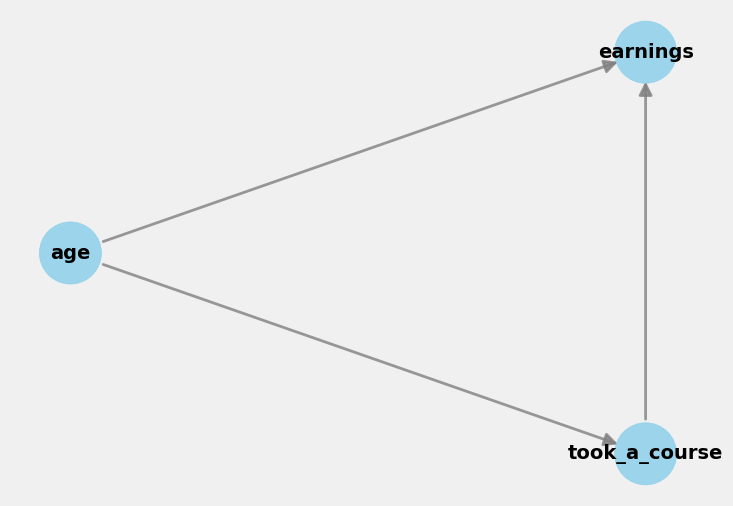

In [12]:
model.view_model()

### **1.3 추정 대상(Estimand) 얻기**

`identify_effect()` 메서드를 사용하여 인과 효과를 식별한다. DoWhy는 정의된 그래프를 분석하여 교란 변수(`age`)를 통제할 수 있는 방법(backdoor 경로)을 찾고, 이에 기반한 추정 대상을 반환한다.

In [13]:
# 추정 대상 얻기
estimand = model.identify_effect()

print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                         
────────────────(E[earnings|age])
d[took_a_course]                 
Estimand assumption 1, Unconfoundedness: If U→{took_a_course} and U→earnings then P(earnings|took_a_course,age,U) = P(earnings|took_a_course,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



### **1.4 효과 추정하기**

`estimate_effect()` 메서드를 사용하여 식별된 인과 효과를 추정한다. 여기서는 `distance_matching`(거리 기반 매칭) 방법을 사용한다. 이는 각 처리군 데이터에 대해 공변량(여기서는 `age`) 공간에서 가장 가까운 통제군 데이터를 찾아 매칭하여 평균 처리 효과(ATE)를 계산한다.

In [14]:
# 추정치 얻기 (Matching)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.distance_matching',
    target_units='ate',
    method_params={'distance_metric': 'minkowski', 'p': 2})

In [15]:
estimate.value

In [16]:
refutation = model.refute_estimate(
    estimand=estimand,
    estimate=estimate,
    method_name='random_common_cause')

In [17]:
print(refutation)

Refute: Add a random common cause
Estimated effect:10464.5
New effect:10344.42415
p value:0.48



## 2. Inverse Probability Weighting (IPW, 역확률 가중법)

### **관련 이론: 역확률 가중법 (IPW)**

IPW는 관찰 연구에서 처리 할당 편향을 보정하여 평균 처리 효과(ATE)를 추정하는 방법이다. 각 개체가 특정 처리를 받을 확률, 즉 \*\*성향 점수(Propensity Score)\*\*를 계산한다. 그 후, 각 개체에 성향 점수의 역수를 가중치로 부여하여 가중 평균을 계산한다.

  - **처리군(T=1)의 가중치:** `1 / P(T=1|X)`
  - **통제군(T=0)의 가중치:** `1 / P(T=0|X)`

이 가중치를 적용하면, 교란 변수(X)의 분포가 두 그룹 간에 유사해지는 가상의 인구 집단이 생성된다. 이 가상 집단에서 결과의 단순 차이를 계산하면 편향이 보정된 인과 효과를 얻을 수 있다.

In [18]:
pd.read_csv('./data/ch_01_drug_data.csv')

gender = [1] * (24 + 56 + 17 + 25) + [0] * (3 + 39 + 6 +74)
clot = [1] * 24 + [0] * 56 + [1] * 17 + [0] * 25 + [1] * 3 + [0] * 39 + [1] * 6 + [0] * 74
drug = [0] * (24 + 56) + [1] * (17 + 25) + [0] * 42 + [1] * 80

drug_data = pd.DataFrame(dict(
    gender=gender,
    clot=clot,
    drug=drug
))

# 그래프 구성 (그래프는 모든 반복에 대해 일정함)
nodes_drug = ['drug', 'clot', 'gender']
edges_drug = [
    ('drug', 'clot'),
    ('gender', 'drug'),
    ('gender', 'clot')
]

# GML 그래프 생성
gml_string_drug = 'graph [directed 1\n'

for node in nodes_drug:
    gml_string_drug += f'\tnode [id "{node}" label "{node}"]\n'

for edge in edges_drug:
    gml_string_drug += f'\tedge [source "{edge[0]}" target "{edge[1]}"]\n'

gml_string_drug += ']'

# CausalModel 인스턴스화
model_drug = CausalModel(
    data=drug_data,
    treatment='drug',
    outcome='clot',
    graph=gml_string_drug
)

# 효과 식별
estimand_drug = model_drug.identify_effect()

# 추정치 얻기 (IPW 가중법)
estimate_drug = model_drug.estimate_effect(
    identified_estimand=estimand_drug,
    method_name='backdoor.propensity_score_weighting',
    target_units='ate'
)

print(estimate_drug.value)

0.048119663707345744


In [19]:
# 추정치 얻기 (IPW 가중법)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.propensity_score_weighting',
    target_units='ate'
)

In [20]:
estimate.value

In [21]:
(estimate.value - 10e3) / 10e3

### 3. S-Learner: The Lone Ranger

### **관련 이론: 메타-학습자 (Meta-Learners)**

메타-학습자는 기존의 지도 학습 모델(예: 선형 회귀, LightGBM, 랜덤 포레스트 등)을 활용하여 CATE(Conditional Average Treatment Effect, 조건부 평균 처리 효과)를 추정하는 프레임워크다. DoWhy의 `econml` 백엔드는 S-Learner, T-Learner, X-Learner와 같은 다양한 메타-학습자를 지원한다.

**S-Learner (Single-Learner)**

S-Learner는 가장 간단한 메타-학습자다. 처리 여부(T)를 다른 공변량(X)들과 동일한 하나의 특성으로 취급하여, 결과(Y)를 예측하는 단일 모델 `M`을 학습시킨다.

`Y ~ M(T, X)`

CATE를 추정하기 위해, 동일한 개체에 대해 처리를 받았을 경우(T=1)의 예측값과 받지 않았을 경우(T=0)의 예측값 간의 차이를 계산한다.

`CATE(X) = M(T=1, X) - M(T=0, X)`

S-Learner는 구현이 간단하지만, 처리 효과가 다른 특성들에 비해 작을 경우 모델이 처리 변수를 무시하여 효과를 제대로 잡아내지 못할 수 있다.

In [22]:
def plot_effect(effect_true, effect_pred, figsize=(10, 7), ylim=(5000, 22000)):
    plt.figure(figsize=figsize)
    plt.scatter(effect_true, effect_pred, color=COLORS[0])
    plt.plot(np.sort(effect_true), np.sort(effect_true), color=COLORS[1], alpha=.7, label='Perfect model')
    plt.xlabel('$True\\ effect$', fontsize=14, alpha=.5)
    plt.ylabel('$Predicted\\ effect$', fontsize=14, alpha=.5)
    plt.ylim(ylim[0], ylim[1])
    plt.legend()
    plt.show()

### **3.1 데이터 읽기**

In [23]:
# 학습 세트
earnings_interaction_train = pd.read_csv('./data/ml_earnings_interaction_train.csv')

# 테스트 세트
earnings_interaction_test = pd.read_csv('./data/ml_earnings_interaction_test.csv')

In [24]:
earnings_interaction_train.shape, earnings_interaction_test.shape

In [25]:
# 학습
earnings_interaction_train.head()

,age,python_proficiency,took_a_course,earnings
0,23,0.632318,True,139267.0
1,20,0.602551,False,115569.0
2,21,0.518225,False,119142.0
3,25,0.945161,False,130291.0
4,30,0.636251,True,164209.0


In [26]:
# 테스트
earnings_interaction_test.head()

,age,python_proficiency,took_a_course,true_effect
0,30,0.223877,True,11120.0
1,23,0.394152,True,11970.0
2,37,0.214638,True,11073.0
3,21,0.869069,True,14345.0
4,41,0.833934,True,14169.0


### **3.2 그래프 정의**

In [27]:
# 그래프 구성 (그래프는 모든 반복에 대해 일정함)
nodes = ['took_a_course', 'python_proficiency', 'earnings', 'age']
edges = [
    ('took_a_course', 'earnings'),
    ('age', 'took_a_course'),
    ('age', 'earnings'),
    ('python_proficiency', 'earnings')
]

# GML 그래프 생성
gml_string = 'graph [directed 1\n'

for node in nodes:
    gml_string += f'\tnode [id "{node}" label "{node}"]\n'

for edge in edges:
    gml_string += f'\tedge [source "{edge[0]}" target "{edge[1]}"]\n'

gml_string += ']'

In [28]:
# CausalModel 인스턴스화
model = CausalModel(
    data=earnings_interaction_train,
    treatment='took_a_course',
    outcome='earnings',
    effect_modifiers='python_proficiency',
    graph=gml_string
)

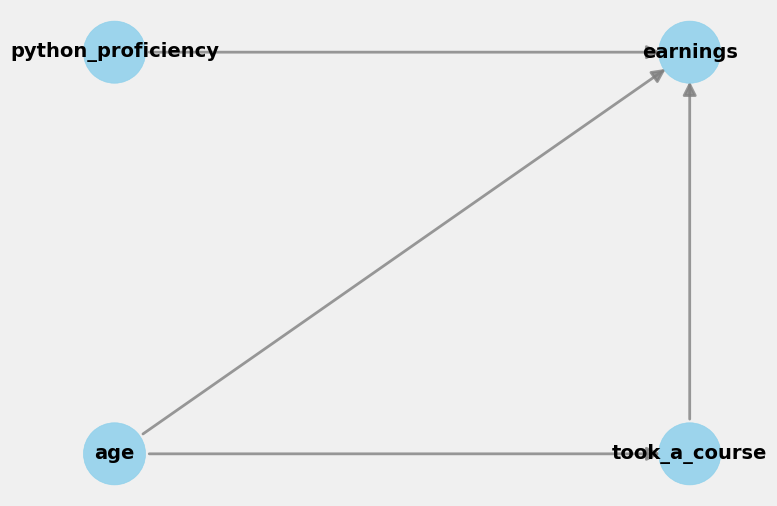

In [29]:
model.view_model()

### **3.3 추정 대상(Estimand) 얻기**

In [30]:
# 추정 대상 얻기
estimand = model.identify_effect()

print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                         
────────────────(E[earnings|age])
d[took_a_course]                 
Estimand assumption 1, Unconfoundedness: If U→{took_a_course} and U→earnings then P(earnings|took_a_course,age,U) = P(earnings|took_a_course,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



### **3.4 효과 추정하기**

In [31]:
# 추정치 얻기 (S-Learner)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.metalearners.SLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'overall_model': LGBMRegressor(n_estimators=500, max_depth=10)
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 5000, number of used features: 4
[LightGBM] [Info] Start training from score 143134.027200
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

추정된 CATE(개별 처리 효과)들의 평균을 계산하여 출력한다.

In [32]:
estimate.cate_estimates.mean()

### **3.5 검증 (Refute)**

In [33]:
refutation = model.refute_estimate(
    estimand=estimand,
    estimate=estimate,
    method_name='placebo_treatment_refuter',
    show_progress_bar=True
)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 5000, number of used features: 4
[LightGBM] [Info] Start training from score 143134.027200
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

`random_common_cause` 방법을 사용하여 이전 셀의 추정치를 다시 검증한다.

In [34]:
print(refutation)

Refute: Use a Placebo Treatment
Estimated effect:12547.068205674783
New effect:12.470599838805763
p value:0.98



이전 셀의 `placebo_treatment_refuter` 결과를 출력한다. p-value가 0.05 이상으로 높게 나타나, 위약 처리의 효과가 0과 유의미하게 다르지 않음을 보여준다. 이는 원래 추정치의 신뢰도를 높인다. 이 셀은 실행되지 않았다.

In [35]:
refutation = model.refute_estimate(
    estimand=estimand,
    estimate=estimate,
    method_name='placebo_treatment_refuter')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 5000, number of used features: 4
[LightGBM] [Info] Start training from score 143134.027200
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

이전 셀의 `placebo_treatment_refuter` 결과를 출력한다.

In [36]:
print(refutation)

Refute: Use a Placebo Treatment
Estimated effect:12547.068205674783
New effect:-22.168734051070533
p value:0.92



#### **3.6 테스트 데이터로 예측**

이 코드 블록은 학습된 모델(`estimate`)을 사용하여 테스트 데이터에 대한 CATE를 예측하려고 시도한다. 그러나 `model.causal_estimator` 속성은 DoWhy의 이전 버전에 존재했던 것으로, 현재 버전에서는 `estimate.estimator`로 접근해야 하므로 `AttributeError`가 발생했다.

In [38]:
# 예측 계산
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1))

# 실제 효과 얻기
effect_true = earnings_interaction_test['true_effect'].values

`estimate.estimator.effect()`를 사용하여 테스트 데이터의 특성들(`true_effect`와 `took_a_course` 제외)을 입력으로 넣어 CATE를 예측한다. `effect_true`에는 테스트 데이터의 실제 효과 값을 저장한다.

In [39]:
# 예측 계산
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# 실제 효과 얻기
effect_true = earnings_interaction_test['true_effect'].values

`mean_absolute_percentage_error` 함수를 사용하여 실제 효과와 예측된 효과 간의 평균 절대 백분율 오차를 계산한다. 이는 모델 예측의 정확도를 평가하는 지표다.

In [40]:
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred)

`plot_effect` 함수를 호출하여 실제 효과와 예측된 효과를 시각적으로 비교한다. 산점도 점들이 대각선에 가까이 분포할수록 모델의 예측이 정확함을 의미한다.

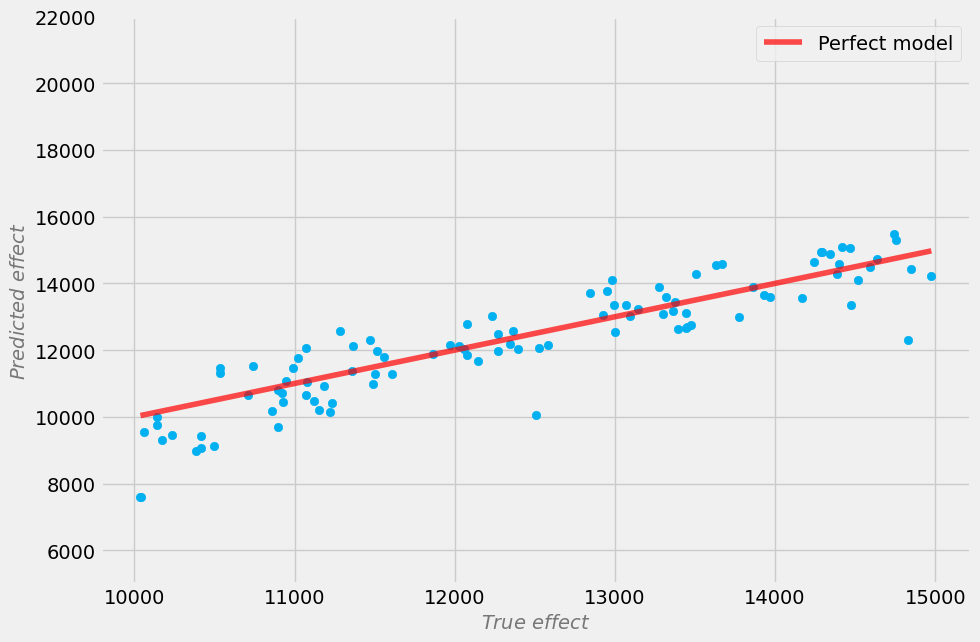

In [41]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

#### **3.7 작은 데이터셋일 경우**

데이터셋의 크기가 작을 때 S-Learner의 성능을 확인하기 위해, 학습 데이터에서 100개의 샘플만 무작위로 추출하여 `CausalModel` 객체(`model_small`)를 생성한다.

In [42]:
# CausalModel 인스턴스화
model_small = CausalModel(
    data=earnings_interaction_train.sample(100),
    treatment='took_a_course',
    outcome='earnings',
    effect_modifiers='python_proficiency',
    graph=gml_string
)

작은 데이터셋으로 S-Learner를 사용하여 인과 효과를 추정한다.

In [43]:
# 추정치 얻기 (S-Learner)
estimate = model_small.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.metalearners.SLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'overall_model': LGBMRegressor(n_estimators=500, max_depth=10)
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 58
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 4
[LightGBM] [Info] Start training from score 143749.480000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

작은 데이터셋으로 학습한 모델을 사용하여 테스트 데이터에 대한 CATE를 예측한다.

In [44]:
# 예측 계산
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# 실제 효과 얻기
effect_true = earnings_interaction_test['true_effect'].values

작은 데이터셋으로 학습했을 때의 예측 성능을 MAPE로 평가한다.

In [45]:
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred)

작은 데이터셋으로 학습한 모델의 예측 결과를 시각화한다. 전체 데이터로 학습했을 때보다 예측의 분산이 커지고 대각선에서 벗어난 점들이 많아진 것을 통해, 데이터 크기가 작아지면 모델 성능이 저하됨을 확인할 수 있다.

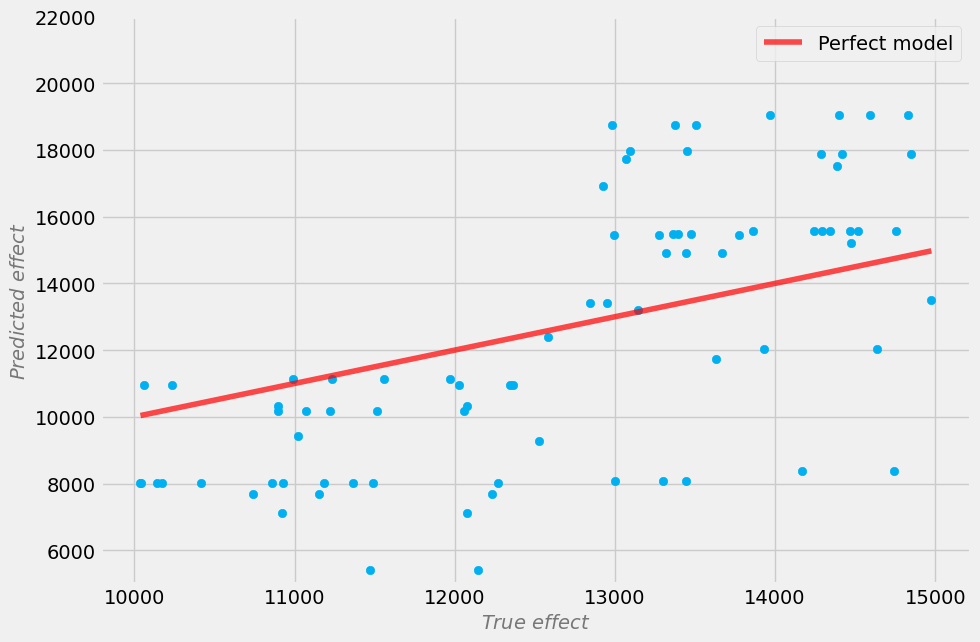

In [46]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)


### **4. T-Learner: Together We Can Do More**

### **관련 이론: T-Learner (Two-Learner)**

T-Learner는 처리군과 통제군에 대해 각각 별도의 모델을 학습하여 CATE를 추정하는 메타-학습자다.

1.  데이터를 처리군(`T=1`)과 통제군(`T=0`)으로 분리한다.
2.  처리군 데이터로 결과(Y)를 예측하는 모델 `M1`을 학습시킨다: `Y1 ~ M1(X)`.
3.  통제군 데이터로 결과(Y)를 예측하는 모델 `M0`을 학습시킨다: `Y0 ~ M0(X)`.
4.  CATE는 두 모델의 예측값 차이로 계산한다:

`CATE(X) = M1(X) - M0(X)`

T-Learner는 S-Learner와 달리 처리 변수의 효과를 직접 모델링하므로, 처리 효과가 비선형적이거나 복잡할 때 더 나은 성능을 보일 수 있다. 하지만, 각 모델이 전체 데이터의 일부만을 사용하여 학습하므로 데이터가 부족할 경우 성능이 저하될 수 있다.


#### **4.1 효과 추정하기**

EconML의 T-Learner를 사용하여 인과 효과를 추정한다. 처리군과 통제군을 위한 두 개의 모델로 `LGBMRegressor`를 각각 지정한다. 이 셀은 실행되지 않았다.

In [47]:
# 추정치 얻기 (T-Learner)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.metalearners.TLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'models': [
                LGBMRegressor(n_estimators=200, max_depth=10),
                LGBMRegressor(n_estimators=200, max_depth=10)
            ]
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 3031, number of used features: 2
[LightGBM] [Info] Start training from score 141133.240845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

추정된 CATE의 평균값을 출력한다.

In [48]:
estimate.cate_estimates.mean()

#### **4.2 테스트 데이터로 예측**

T-Learner로 학습한 모델을 사용하여 테스트 데이터의 CATE를 예측한다.

In [49]:
# 예측 계산
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# 실제 효과 얻기
effect_true = earnings_interaction_test['true_effect'].values

T-Learner의 예측 성능을 MAPE로 평가한다.

In [50]:
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred)

T-Learner의 예측 결과를 시각화한다. S-Learner와 비교하여 예측 성능을 평가할 수 있다.

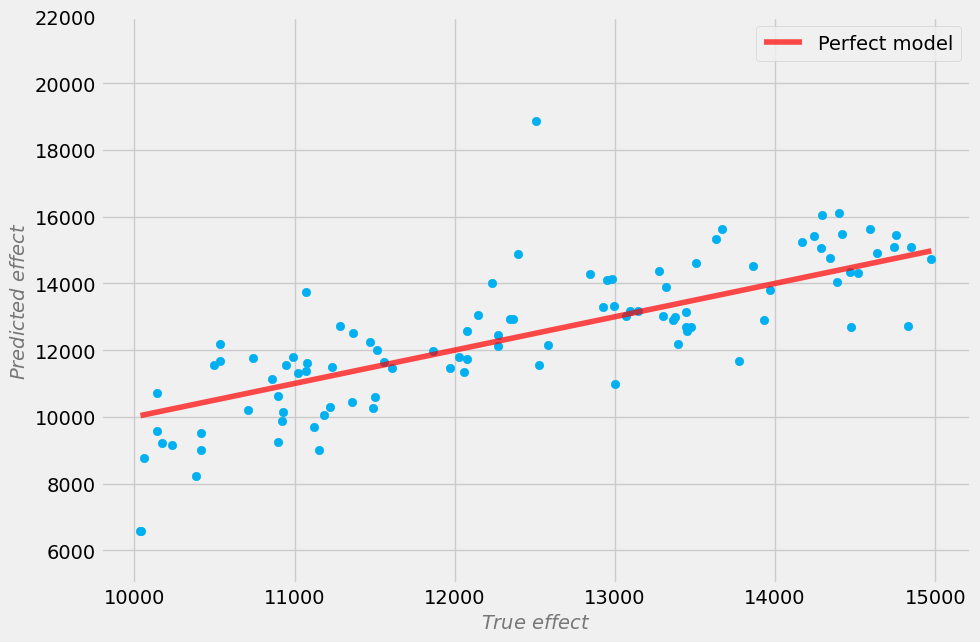

In [51]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

### **5. X-Learner: A Step Further**

### **관련 이론: X-Learner**

X-Learner는 S-Learner와 T-Learner의 장점을 결합한 더 정교한 메타-학습자로, 다음과 같은 3단계로 구성된다.

1.  **1단계:** T-Learner와 동일하게 처리군 모델(`M1`)과 통제군 모델(`M0`)을 각각 학습시킨다.
2.  **2단계:**
      * 처리군에 대해 `imputed treatment effect`를 계산한다: `D1 = Y1 - M0(X1)`.
      * 통제군에 대해 `imputed treatment effect`를 계산한다: `D0 = M1(X0) - Y0`.
      * 처리군의 특성(`X1`)을 사용하여 `D1`을 예측하는 모델 `M_tau1`을 학습시킨다.
      * 통제군의 특성(`X0`)을 사용하여 `D0`을 예측하는 모델 `M_tau0`을 학습시킨다.
3.  **3단계:** 성향 점수(`g(x) = P(T=1|X)`)를 가중치로 사용하여 두 효과 모델의 예측을 결합한다.

`CATE(X) = g(x) * M_tau0(X) + (1 - g(x)) * M_tau1(X)`

X-Learner는 한 그룹의 데이터가 다른 그룹보다 훨씬 많을 때나 처리 효과가 이질적(heterogeneous)일 때 특히 좋은 성능을 보인다.



#### **5.1 효과 추정하기**

EconML의 X-Learner를 사용하여 인과 효과를 추정한다. 결과 모델(`models`)과 CATE 모델(`cate_models`)에 대해 `LGBMRegressor`를 지정한다.

In [52]:
# 추정치 얻기 (X-Learner)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.metalearners.XLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'models': [
                LGBMRegressor(n_estimators=50, max_depth=10),
                LGBMRegressor(n_estimators=50, max_depth=10)
            ],
            'cate_models': [
                LGBMRegressor(n_estimators=50, max_depth=10),
                LGBMRegressor(n_estimators=50, max_depth=10)
            ]
        },
        'fit_params': {},
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 3031, number of used features: 2
[LightGBM] [Info] Start training from score 141133.240845
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 285
[LightGBM] [Info] Number of data points in the train set: 1969, number of used features: 2
[LightGBM] [Info] Start training from score 146213.957847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in

X-Learner의 간소화된 버전으로, 모든 내부 모델에 동일한 모델(`LGBMRegressor`)을 사용하도록 지정한다. 이는 이전 셀과 동일한 작업을 수행한다.

In [53]:
# 단일 모델로 지정한 X-Learner - 위 셀과 동일
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.metalearners.XLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'models': LGBMRegressor(n_estimators=50, max_depth=10),
        },
        'fit_params': {},
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000353 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 3031, number of used features: 2
[LightGBM] [Info] Start training from score 141133.240845
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 285
[LightGBM] [Info] Number of data points in the train set: 1969, number of used features: 2
[LightGBM] [Info] Start training from score 146213.957847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in

In [54]:
estimate.cate_estimates.mean()

### **5.2 테스트 데이터로 예측**

X-Learner로 학습한 모델을 사용하여 테스트 데이터의 CATE를 예측한다.

In [55]:
# 예측 계산
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# 실제 효과 얻기
effect_true = earnings_interaction_test['true_effect'].values

In [56]:
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred)

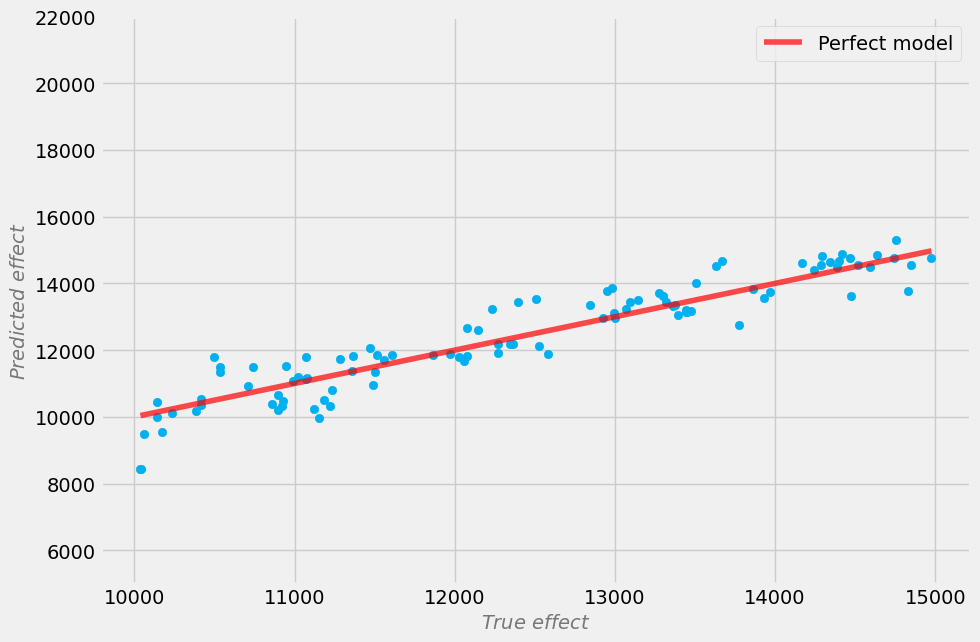

In [57]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

### **5.3 작은 데이터에 대한 X-Learner**

작은 데이터셋(100개 샘플)에 대해 X-Learner를 사용하여 인과 효과를 추정한다. 이 셀은 실행되지 않았다.

In [58]:
# 추정치 얻기 (X-Learner)
estimate = model_small.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.metalearners.XLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'models': LGBMRegressor(n_estimators=50, max_depth=10)
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000943 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36
[LightGBM] [Info] Number of data points in the train set: 60, number of used features: 2
[LightGBM] [Info] Start training from score 142121.183333
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [59]:
# 예측 계산
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1))

# 실제 효과 얻기
effect_true = earnings_interaction_test['true_effect'].values

In [60]:
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred)

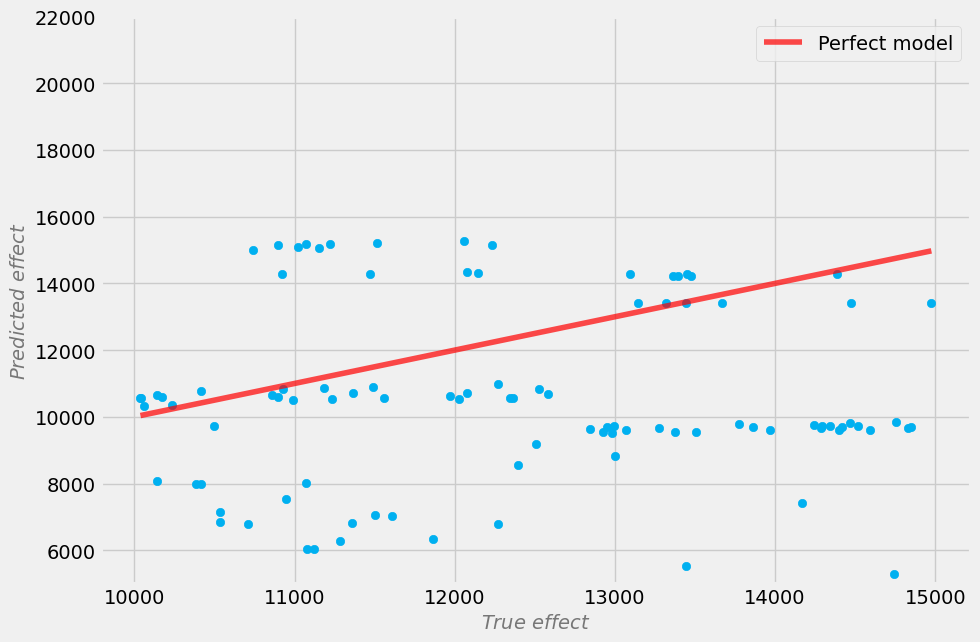

In [61]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

## **6. 실험 데이터를 이용한 메타-학습자 (케빈 힐스트롬 데이터)**

In [63]:
# 데이터 읽기
hillstrom_clean = pd.read_csv('./data/hillstrom_clean.csv')

# 레이블 매핑 읽기
with open('./data/hillstrom_clean_label_mapping.json', 'r') as f:
    hillstrom_labels_mapping = json.load(f)

In [64]:
hillstrom_clean.head()

,recency,history,mens,womens,newbie,visit,conversion,spend,zip_code__rural,zip_code__surburban,zip_code__urban,channel__multichannel,channel__phone,channel__web,treatment
0,10,142.44,1,0,0,0,0,0.0,0,1,0,0,1,0,1
1,6,329.08,1,1,1,0,0,0.0,1,0,0,0,0,1,0
2,7,180.65,0,1,1,0,0,0.0,0,1,0,0,0,1,1
3,9,675.83,1,0,1,0,0,0.0,1,0,0,0,0,1,2
4,2,45.34,1,0,0,0,0,0.0,0,0,1,0,0,1,1


In [65]:
hillstrom_clean.columns

Index(['recency', 'history', 'mens', 'womens', 'newbie', 'visit', 'conversion',
       'spend', 'zip_code__rural', 'zip_code__surburban', 'zip_code__urban',
       'channel__multichannel', 'channel__phone', 'channel__web', 'treatment'],
      dtype='object')

## **7. 이중 강건 방법 (Doubly Robust Methods)**

### **관련 이론: 이중 강건 학습자 (Doubly Robust Learner)**

이중 강건(Doubly Robust, DR) 방법은 CATE를 추정하는 또 다른 정교한 기법이다. 이 방법은 두 개의 보조 모델을 사용한다.

1.  **결과 모델(Outcome Model):** `Y ~ M_y(X)`
2.  **성향 모델(Propensity Model):** `T ~ M_t(X)`

이 두 모델을 사용하여 결과를 다음과 같이 변환한다.

`Y* = Y - M_y(X) + (T - g(X)) / (g(X) * (1 - g(X)))`

(위 식은 단순화된 형태로 실제 DR-Learner의 계산은 더 복잡하다.)

DR-Learner는 결과 모델(`M_y`) 또는 성향 모델(`M_t`) 중 **하나만 올바르게 명시되어도** 일관된(consistent) 추정치를 제공하는 '이중 강건' 특성을 가진다. 두 모델이 모두 잘못 명시되더라도, 둘 중 하나가 어느 정도 정확하다면 다른 방법보다 더 나은 성능을 보이는 경향이 있다.


### **7.1 효과 추정하기**

EconML의 `DRLearner`(이중 강건 학습자)를 사용하여 인과 효과를 추정한다. 성향 모델(`model_propensity`)로는 `LogisticRegression`을, 결과 모델(`model_regression`)로는 `LGBMRegressor`를 지정한다. 이 셀은 실행되지 않았다.

In [66]:
# 추정치 얻기 (Doubly robust)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dr.DRLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'model_propensity': LogisticRegression(),
            'model_regression': LGBMRegressor(n_estimators=1000, max_depth=10)
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 2500, number of used features: 3
[LightGBM] [Info] Start training from score 143188.292000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [67]:
estimate.cate_estimates.mean()

### **7.2 테스트 데이터로 예측**

DR-Learner로 학습한 모델을 사용하여 테스트 데이터의 CATE를 예측한다.

In [68]:
# 예측 계산
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1))

# 실제 효과 얻기
effect_true = earnings_interaction_test['true_effect'].values

In [69]:
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred)

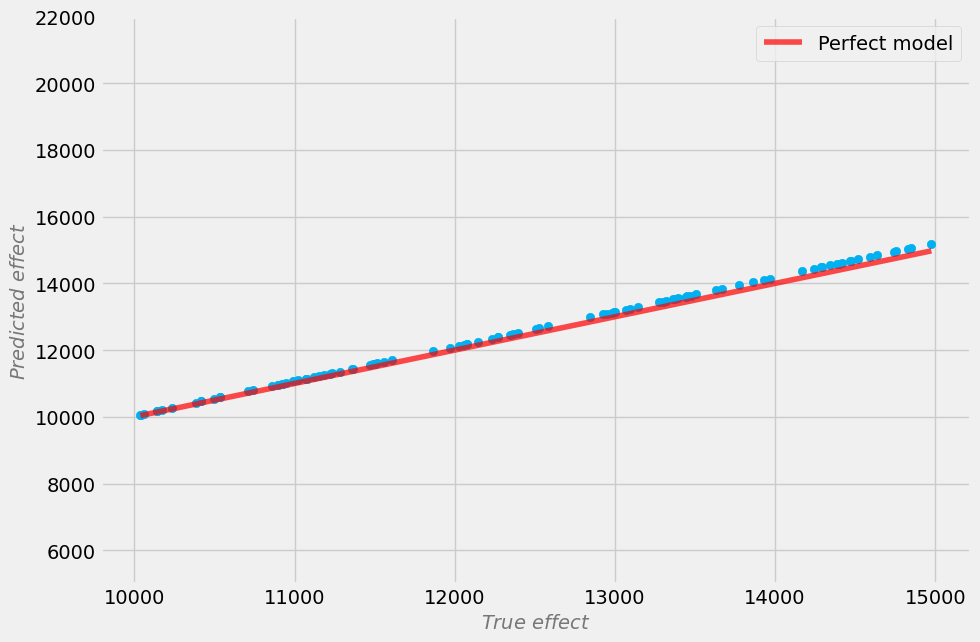

In [70]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

## **8. Double Machine Learning (DML)**

### **관련 이론: 이중 머신러닝 (Double Machine Learning, DML)**

DML은 편향되지 않은(unbiased) CATE 추정을 위해 잔차(residual) 개념을 활용하는 방법이다.

1.  **1단계:** 교란 변수(W)를 사용하여 결과(Y)를 예측하는 모델(`M_y`)과 처리(T)를 예측하는 모델(`M_t`)을 각각 학습시킨다.
2.  **2단계:** 각 모델의 예측 오차, 즉 잔차를 계산한다.
      * `Y_tilde = Y - M_y(W)`
      * `T_tilde = T - M_t(W)`
3.  **3단계:** Y의 잔차를 T의 잔차에 대해 회귀 분석하여 CATE를 추정한다.

`Y_tilde = theta * T_tilde`

여기서 `theta`가 바로 CATE 추정치가 된다. DML은 교차 적합(cross-fitting)과 같은 기법을 사용하여 과적합을 방지하고, 복잡한 비선형 관계가 존재하는 상황에서도 강건한 추정치를 제공한다. `LinearDML`은 마지막 단계에서 선형 모델을 사용한다.


### **8.1 효과 추정하기**

EconML의 `LinearDML`을 사용하여 인과 효과를 추정한다. 결과 모델(`model_y`)과 처리 모델(`model_t`)에 `LGBMRegressor`를 사용한다. DML은 내부적으로 교차 적합을 수행하여 모델의 편향을 줄인다. 이 셀은 실행되지 않았다.

In [71]:
# 추정치 얻기 (DML)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.LinearDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LGBMRegressor(n_estimators=500, max_depth=10),
            'model_t': LGBMRegressor(n_estimators=500, max_depth=10),
        },
        'fit_params': {}
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 2500, number of used features: 2
[LightGBM] [Info] Start training from score 0.396000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [72]:
estimate.cate_estimates.mean()

### **8.2 테스트 데이터로 예측**

DML로 학습한 모델을 사용하여 테스트 데이터의 CATE를 예측한다.

In [74]:
# 예측 계산
effect_pred = estimate.estimator.effect(
    earnings_interaction_test.drop(['true_effect', 'took_a_course'], axis=1)
)

# 실제 효과 얻기
effect_true = earnings_interaction_test['true_effect'].values

In [75]:
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred)

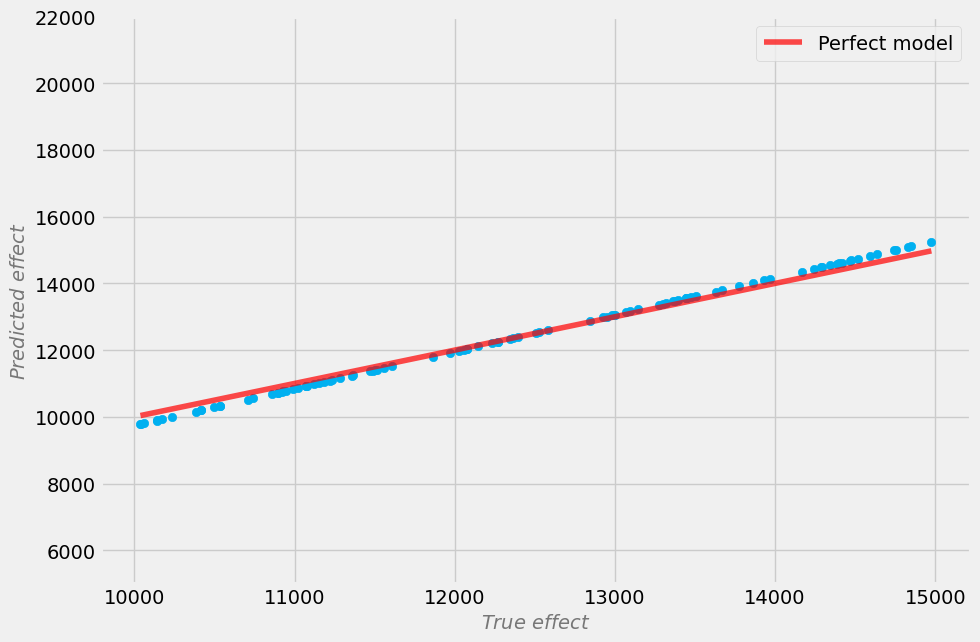

In [76]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
)

## **9. 실제 환경에서의 매칭 - 시뮬레이션**

### **매칭 성공 확률**

이 섹션은 특성의 차원(dimensionality)이 증가함에 따라 완벽한 매칭을 찾을 확률이 얼마나 급격히 감소하는지를 시뮬레이션을 통해 보여준다.

In [77]:
results_per_dimension = {}

for d in range(2, 19):
    results = []

    N_SAMPLES = 1000
    DIM_X = d

    for i in tqdm(range(100)):
        X = np.random.binomial(n=1, p=.5, size=(N_SAMPLES, DIM_X))

        local_results = []
        for row in range(X.shape[0]):
            # `row`에 대해 최소 1개의 매칭을 찾았는가?
            success = (np.where(np.where(X == X[row], 1, 0).sum(axis=1) == DIM_X, 1, 0).sum() - 1) > 0
            local_results.append(success)

        results.append(np.array(local_results).mean())

    results_per_dimension[d] = results

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [78]:
# 통계 계산
mean_p = pd.DataFrame(results_per_dimension).mean(axis=0).values
sd_p = pd.DataFrame(results_per_dimension).std(axis=0).values

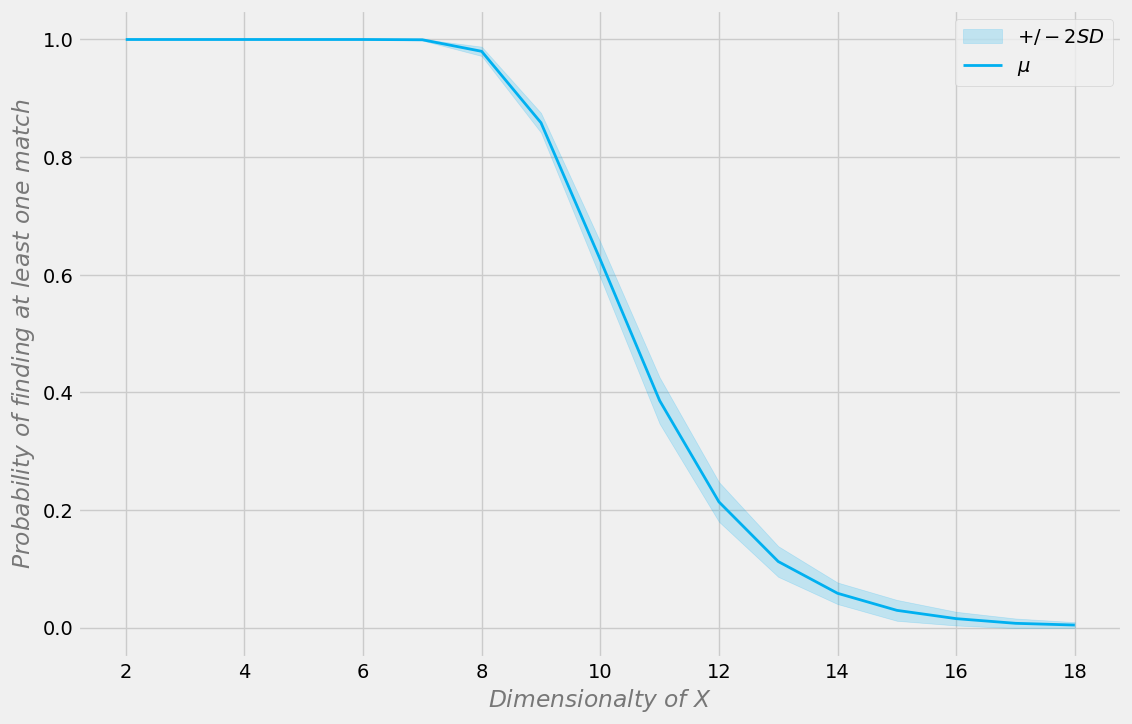

In [79]:
# 플롯
plt.figure(figsize=(12, 8))
plt.fill_between(
    range(2, 19),
    mean_p - sd_p*2,
    mean_p + sd_p*2,
    color=COLORS[0],
    alpha=.2,
    label='$+/-2SD$'
)
plt.plot(range(2, 19), mean_p, color=COLORS[0], lw=2, label='$\\mu$')
plt.legend()
plt.xlabel('$Dimensionalty \\ of \\ X$', alpha=.5)
plt.ylabel('$Probability \\ of \\ finding \\ at \\ least \\ one \\ match$', alpha=.5)
plt.show()